# Natural data - retweeted mostly or somewhat more by Republican registered users

In [47]:
import sys
sys.path.insert(0,'..')

Imports:

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import json


from emoatlas import *
import nltk
import networkx as nx

Import stopwords to look at non-stopwords focal terms later:

In [49]:
from nltk.corpus import stopwords

# NLTK resources commonly needed for EmoAtlas + downstream text filtering
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

SPACY_MODEL = "en_core_web_sm"

# shortcut for eomatlas, using the default English spacy model
emo = EmoScores(language="english", spacy_model=SPACY_MODEL)


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Now load the JSON file containing the real titles retrieved through MediaCloud, different structure from the synthetic datasets

In [ ]:
with open(r"../data/real_rep_titles.json", "r") as f:
    data = json.load(f)
df=pd.DataFrame(data)
print(df.head())

                                                  id  \
0  652bf76c68f140dba409c421f3f391f3a7d4bda9e38b2c...   
1  072a271b7f69a5650aed36b3f2d37101bc94a906a1627d...   
2  0de86dccfbc64d49c8d7fdea2f1e920ed448c9be0cc8b5...   
3  13a72bd7e98b699459167a95ddacbb9e7f570a6e5d3333...   
4  a44c4bae87d314d38e40c5bc72a83d969752532bd4791b...   

                       indexed_date language          media_name  \
0  2025-07-23T09:10:22.900857+00:00       en       investors.com   
1  2025-08-04T18:54:28.093513+00:00       en         newsmax.com   
2  2025-07-10T15:12:40.185406+00:00       en     dailycaller.com   
3  2025-07-07T02:54:22.017476+00:00       en  thenewamerican.com   
4  2025-06-23T15:30:11.875382+00:00       en        redstate.com   

            media_url publish_date  \
0       investors.com   2016-04-22   
1         newsmax.com   2016-04-22   
2     dailycaller.com   2016-04-22   
3  thenewamerican.com   2016-04-22   
4        redstate.com   2016-04-22   

                         

In [51]:
df_2016 = pd.DataFrame(df[df['publish_date'] == "2016-04-22"]["title"])
df_2017 = pd.DataFrame(df[df['publish_date'] == "2017-04-22"]["title"])

print(df_2016.head())
print(df_2017.head())

                                               title
0  The Horror! Climate Change Is Making The Weath...
1  Weather Channel Founder: Get Politics Out of C...
2  New Global Warming Temperature Target Could Co...
3  U.S. Signs UN Climate Pact Blasted as Disastro...
4     Earth Day and Climate Change: A Political Scam
                                                title
53  Earth Day Horrors: Killer Cereal, Deaf Fish, a...
54                           Obama Plans Return to...
55  March for Science takes aim at climate-skeptic...
56  Shocking: Bill Nye, no longer hanging around W...
57  The Marches For Democrats, As Reported By Libe...


Join all the titles from each year to work with them as a list

In [52]:
titles_2016 = ' '.join(df_2016['title'].tolist())
titles_2017 = ' '.join(df_2017['title'].tolist())

2016 data, emotional flower:

Emotional words count:

{'anger': 13, 'trust': 33, 'surprise': 11, 'disgust': 8, 'joy': 22, 'sadness': 14, 'fear': 22, 'anticipation': 17}


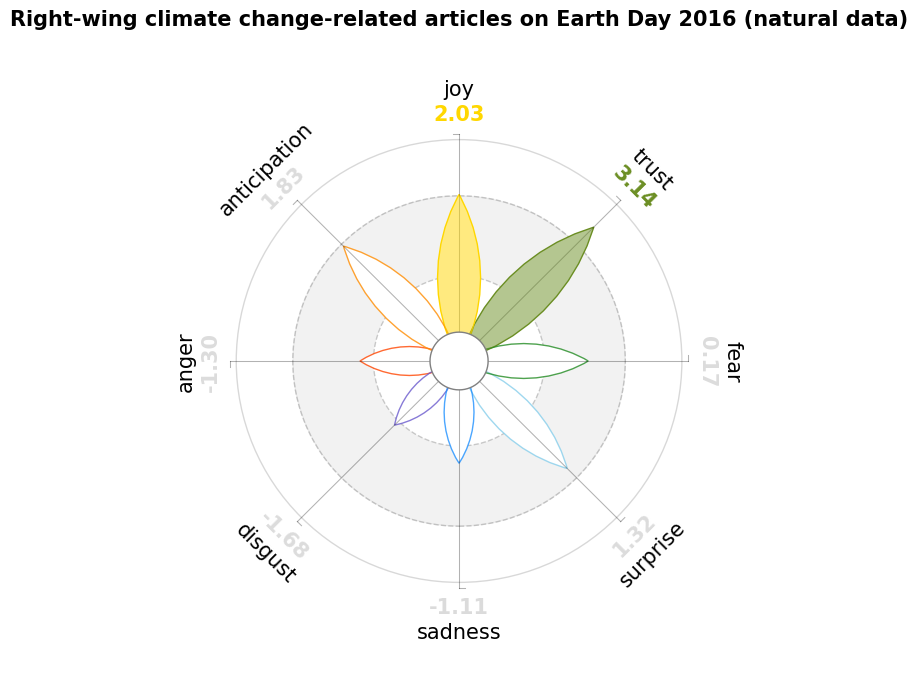

In [53]:
fmnt_2016 = emo.formamentis_network(titles_2016)

emotion_counts_2016 = emo.emotions(titles_2016)
print('Emotional words count:\n')
print(emotion_counts_2016)
zscores_2016 = emo.zscores(titles_2016)
emo.draw_statistically_significant_emotions(fmnt_2016, title='Right-wing climate change-related articles on Earth Day 2016 (natural data)')

Network statistics analysis:

In [54]:
# rank salient terms (closeness centrality)
graph_2016 = emo.formamentis_to_nxgraph(fmnt_2016)
degree_dict = dict(graph_2016.degree())
closeness_dict = nx.closeness_centrality(graph_2016)

top_terms_df_2016 = pd.DataFrame(
    {
        "term": list(graph_2016.nodes()),
        "degree": [degree_dict[node] for node in graph_2016.nodes()],
        "closeness": [closeness_dict[node] for node in graph_2016.nodes()],
    }
)

# filter to only alphabetic and non-stopword
top_terms_df_2016["is_alpha"] = top_terms_df_2016["term"].astype(str).str.fullmatch(r"[A-Za-z]+")
top_terms_df_2016["usable_term"] = (
    top_terms_df_2016["is_alpha"].fillna(False)
    & (~top_terms_df_2016["term"].astype(str).str.lower().isin(stop_words))
    & (top_terms_df_2016["term"].astype(str).str.len() >= 4)
)

top_terms_df_2016 = top_terms_df_2016.sort_values(["degree", "closeness"], ascending=False).reset_index(drop=True)

print("Graph size:")
print("Nodes:", graph_2016.number_of_nodes())
print("Edges:", graph_2016.number_of_edges())

top_terms_df_2016 = top_terms_df_2016.loc[top_terms_df_2016["usable_term"]].reset_index(drop=True)
print("\nTop alphabetic, non-stopword terms, by saliency:")
display(top_terms_df_2016.head(10))

Graph size:
Nodes: 234
Edges: 1175

Top alphabetic, non-stopword terms, by saliency:


,term,degree,closeness,is_alpha,usable_term
0,change,58,0.476298,True,True
1,sign,48,0.460168,True,True
2,climate,48,0.456530,True,True
3,earth,43,0.487351,True,True
4,obama,33,0.430176,True,True
5,fight,33,0.404561,True,True
6,expose,32,0.416975,True,True
7,rally,32,0.408857,True,True
8,celebrate,29,0.412508,True,True
9,talk,28,0.427786,True,True


The most salient word is *change*, which is the focal term. Let's look at its semantic frame and at the most significant emotions the frame conveys. 

Semantic frame theory affirms that it is possible to partly reconstruct the meaning of a word based on its textual context

In [55]:
if top_terms_df_2016.empty:
    raise ValueError("No usable focal term was found in the combined network.")

focal_term = top_terms_df_2016.iloc[0]["term"]
focal_fmn = emo.extract_word_from_formamentis(fmnt_2016, focal_term)
# only taking the connection to focal_term


if not focal_fmn.vertices:
    raise ValueError(f"No semantic frame could be extracted for term: {focal_term}")

print("Chosen focal term:", focal_term)
print("Semantic-frame vertices:", len(focal_fmn.vertices))
print("Semantic-frame terms:", sorted(focal_fmn.vertices))

Chosen focal term: change
Semantic-frame vertices: 59
Semantic-frame terms: ['ag', 'agenda', 'agreement', 'alarmism', 'americans', 'bailey', 'baldwin', 'big', 'billion', 'blast', 'brutal', 'care', 'cartoon', 'celebrate', 'change', 'claim', 'climate', 'cost', 'crush', 'day', 'denial', 'describe', 'die', 'earth', 'expose', 'family', 'fight', 'find', 'form', 'founder', 'fraud', 'funny', 'his', 'ill', 'inquisition', 'liberal', 'meme', 'not-lecture', 'obama', 'ocean', 'pact', 'panel', 'paris', 'pay', 'people', 'praise', 'president', 'pro', 'scam', 'sign', 'skeptic', 'soar', 'talk', 'teach', 'threat', 'victim', 'violate', 'want', 'weather']


Textual Forma Mentis Network of the most salient words linked to the focal word (given the size of the dataset, looking at the whole semantic frame would be useless). The words taken into accounts are all those with a top 25% salience (over the 75% quantile).

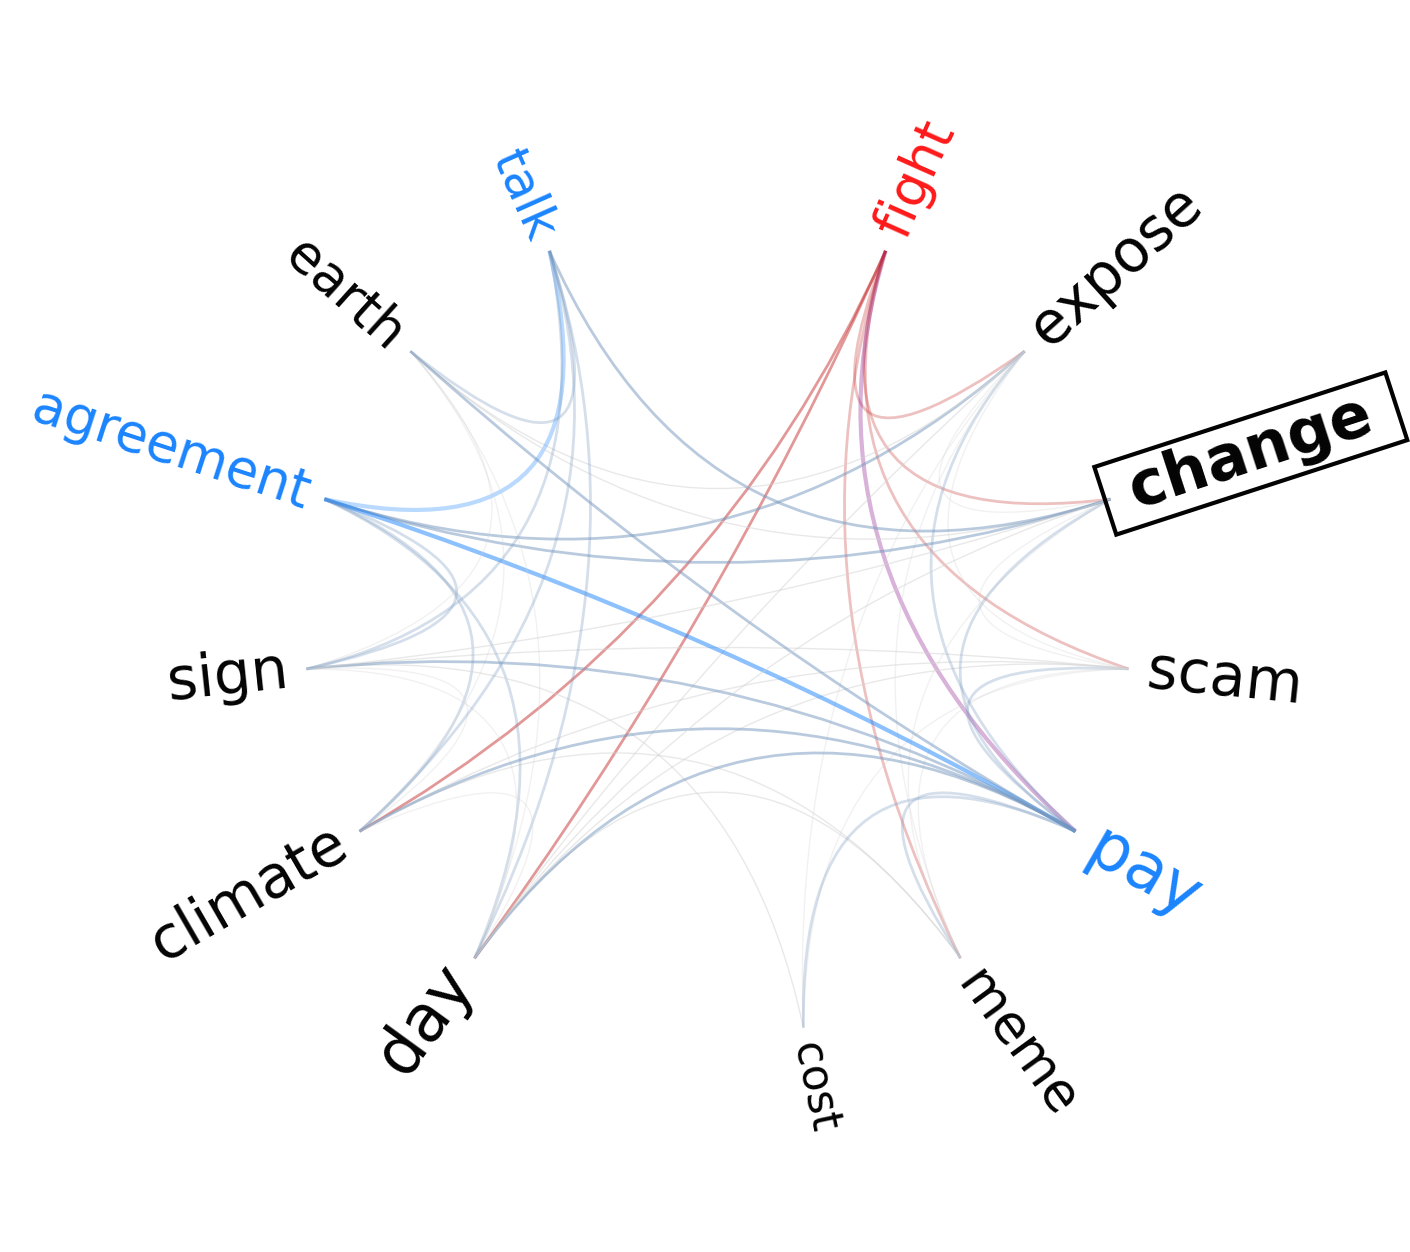

In [56]:
focal_graph = emo.formamentis_to_nxgraph(focal_fmn)
closeness_dict = nx.closeness_centrality(focal_graph)

top_terms_df_focal = pd.DataFrame(
    {
        "term": list(focal_graph.nodes()),
        "closeness": [closeness_dict[node] for node in focal_graph.nodes()],
    }
)

# go over all the edges, only keep the ones with third quartile salience
t=np.quantile(list(top_terms_df_focal['closeness']),0.75)
df_t=top_terms_df_focal[top_terms_df_focal['closeness']>t]
top_edges=[]
top_nodes=df_t['term'][:10]



for v in top_nodes:
    for (e1,e2) in list(focal_graph.edges):
        if v in (e1,e2):
                    if e1 in list(df_t['term']) and e2 in list(df_t['term']):
                             top_edges.append((e1,e2))

top_graph=nx.Graph()
top_graph.add_nodes_from(top_nodes)
top_graph.add_edges_from(top_edges)

top_focal_fmnt=emo.nxgraph_to_formamentis(top_graph)

top_edges
emo.draw_formamentis(top_focal_fmnt, highlight=[focal_term])


Emotional flower of the semantic frame:

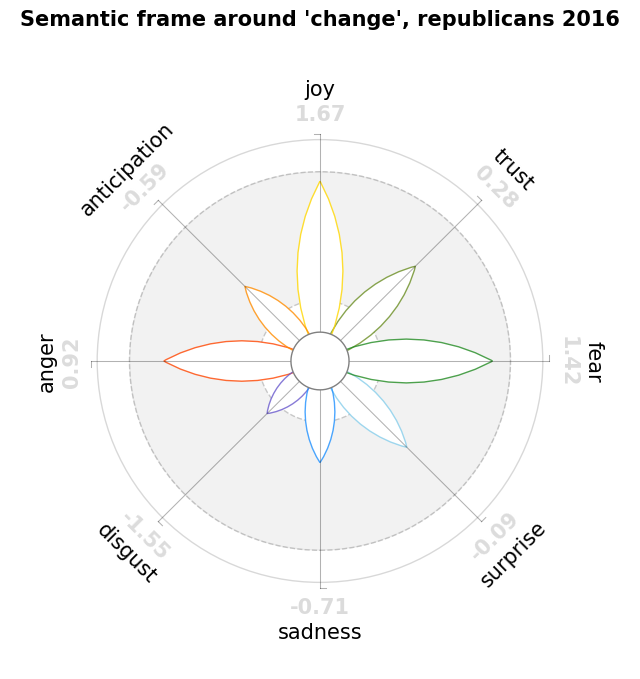

In [57]:
# Important:
# draw_formamentis_flower() expects raw text and rebuilds a new network from that text.
# Here we already have the extracted semantic-frame network, so the correct call is to pass
# the Formamentis Network directly to draw_statistically_significant_emotions().
emo.draw_statistically_significant_emotions(
    focal_fmn,
    title=f"Semantic frame around '{focal_term}', republicans 2016",
)

Now let's do the same for 2017 data.

First, emotional flower

Emotional words count:

{'anger': 15, 'trust': 15, 'surprise': 7, 'disgust': 8, 'joy': 10, 'sadness': 14, 'fear': 20, 'anticipation': 10}


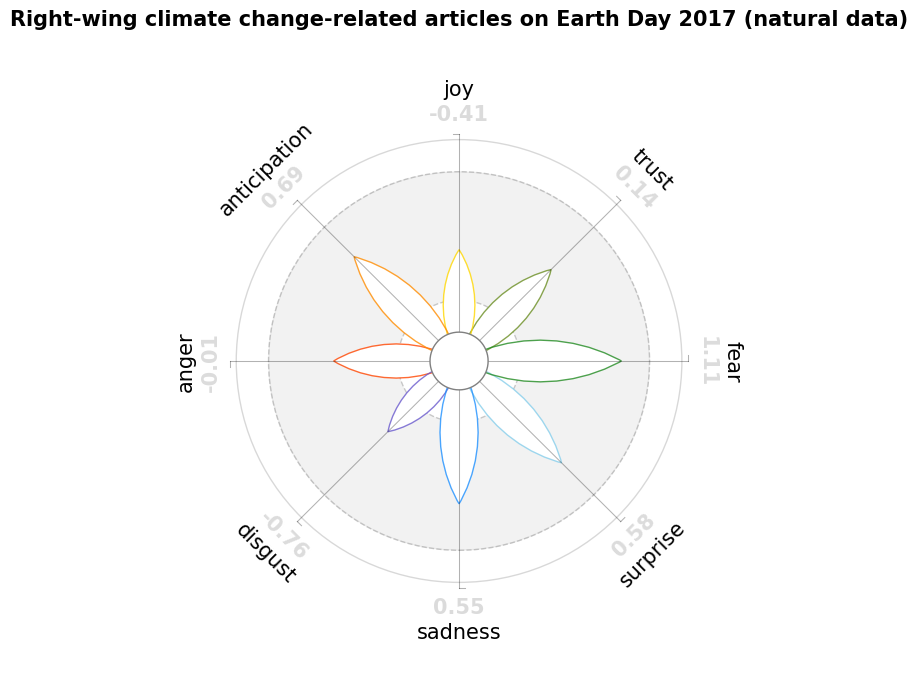

In [58]:
fmnt_2017 = emo.formamentis_network(titles_2017)
emotion_counts_2017 = emo.emotions(titles_2017)
print('Emotional words count:\n')
print(emotion_counts_2017)
zscores_2017 = emo.zscores(titles_2017)
emo.draw_statistically_significant_emotions(fmnt_2017, title='Right-wing climate change-related articles on Earth Day 2017 (natural data)')

Network statistics analysis:

In [59]:
# rank salient terms (closeness centrality)
graph_2017 = emo.formamentis_to_nxgraph(fmnt_2017)
degree_dict = dict(graph_2017.degree())
closeness_dict = nx.closeness_centrality(graph_2017)

top_terms_df_2017 = pd.DataFrame(
    {
        "term": list(graph_2017.nodes()),
        "degree": [degree_dict[node] for node in graph_2017.nodes()],
        "closeness": [closeness_dict[node] for node in graph_2017.nodes()],
    }
)

# filter to only alphabetic and non-stopword
top_terms_df_2017["is_alpha"] = top_terms_df_2017["term"].astype(str).str.fullmatch(r"[A-Za-z]+")
top_terms_df_2017["usable_term"] = (
    top_terms_df_2017["is_alpha"].fillna(False)
    & (~top_terms_df_2017["term"].astype(str).str.lower().isin(stop_words))
    & (top_terms_df_2017["term"].astype(str).str.len() >= 4)
)

top_terms_df_2017 = top_terms_df_2017.sort_values(["degree", "closeness"], ascending=False).reset_index(drop=True)

print("Graph size:")
print("Nodes:", graph_2017.number_of_nodes())
print("Edges:", graph_2017.number_of_edges())

filtered_terms_df_2017 = top_terms_df_2017.loc[top_terms_df_2017["usable_term"]].reset_index(drop=True)
print("\nTop alphabetic, non-stopword terms, by saliency:")
display(filtered_terms_df_2017.head(10))



Graph size:
Nodes: 254
Edges: 1301

Top alphabetic, non-stopword terms, by saliency:


,term,degree,closeness,is_alpha,usable_term
0,march,111,0.584296,True,True
1,science,49,0.476460,True,True
2,gather,42,0.484674,True,True
3,earth,42,0.479167,True,True
4,thousand,39,0.442308,True,True
5,destroy,36,0.460000,True,True
6,return,36,0.443082,True,True
7,protester,34,0.450178,True,True
8,blow,34,0.446996,True,True
9,trump,32,0.449378,True,True


The most salient word is *march*, this time. Let's look at reduced FMNT (with the same third quartile threshold as before) and emotional flower of the semantic frame.

In [60]:
if top_terms_df_2017.empty:
    raise ValueError("No usable focal term was found in the combined network.")

focal_term = top_terms_df_2017.iloc[0]["term"]
focal_fmn = emo.extract_word_from_formamentis(fmnt_2017, focal_term)
# only taking the connection to focal_term


if not focal_fmn.vertices:
    raise ValueError(f"No semantic frame could be extracted for term: {focal_term}")

print("Chosen focal term:", focal_term)
print("Semantic-frame vertices:", len(focal_fmn.vertices))
print("Semantic-frame terms:", sorted(focal_fmn.vertices))

Chosen focal term: march
Semantic-frame vertices: 112
Semantic-frame terms: ['aim', 'alarm', 'alarmist', 'anti', 'anti-', 'attract', 'berlin', 'bill', 'blow', 'brave', 'budget', 'child', 'college', 'completely', 'counter', 'cut', 'day', 'demand', 'democrat', 'demonstrator', 'destroy', 'double', 'draw', 'drop', 'earth', 'england', 'entertainer', 'epa', 'event', 'exhibit', 'fight', 'flood', 'form', 'gather', 'globe', 'great', 'hang', 'happen', 'heat', 'historian', 'hollywood', 'host', 'huxley', 'imf', 'join', 'l.a', 'late', 'lead', 'leave', 'liberalism', 'local', 'long', 'march', 'marcher', 'marchforscience', 'nationwide', 'new', 'news', 'nye', 'open', 'orwell', 'place', 'plan', 'pledge', 'political', 'pretty', 'promote', 'protest', 'protester', 'pruitt', 'pseudo', 'qualify', 'rally', 'reactor', 'recognize', 'refuse', 'remember', 'report', 'resist', 'return', 'riot', 'sarasota', 'science', 'scientist', 'shocking', 'skepticism', 'socialist', 'state', 'stop', 'street', 'strike', 'support',

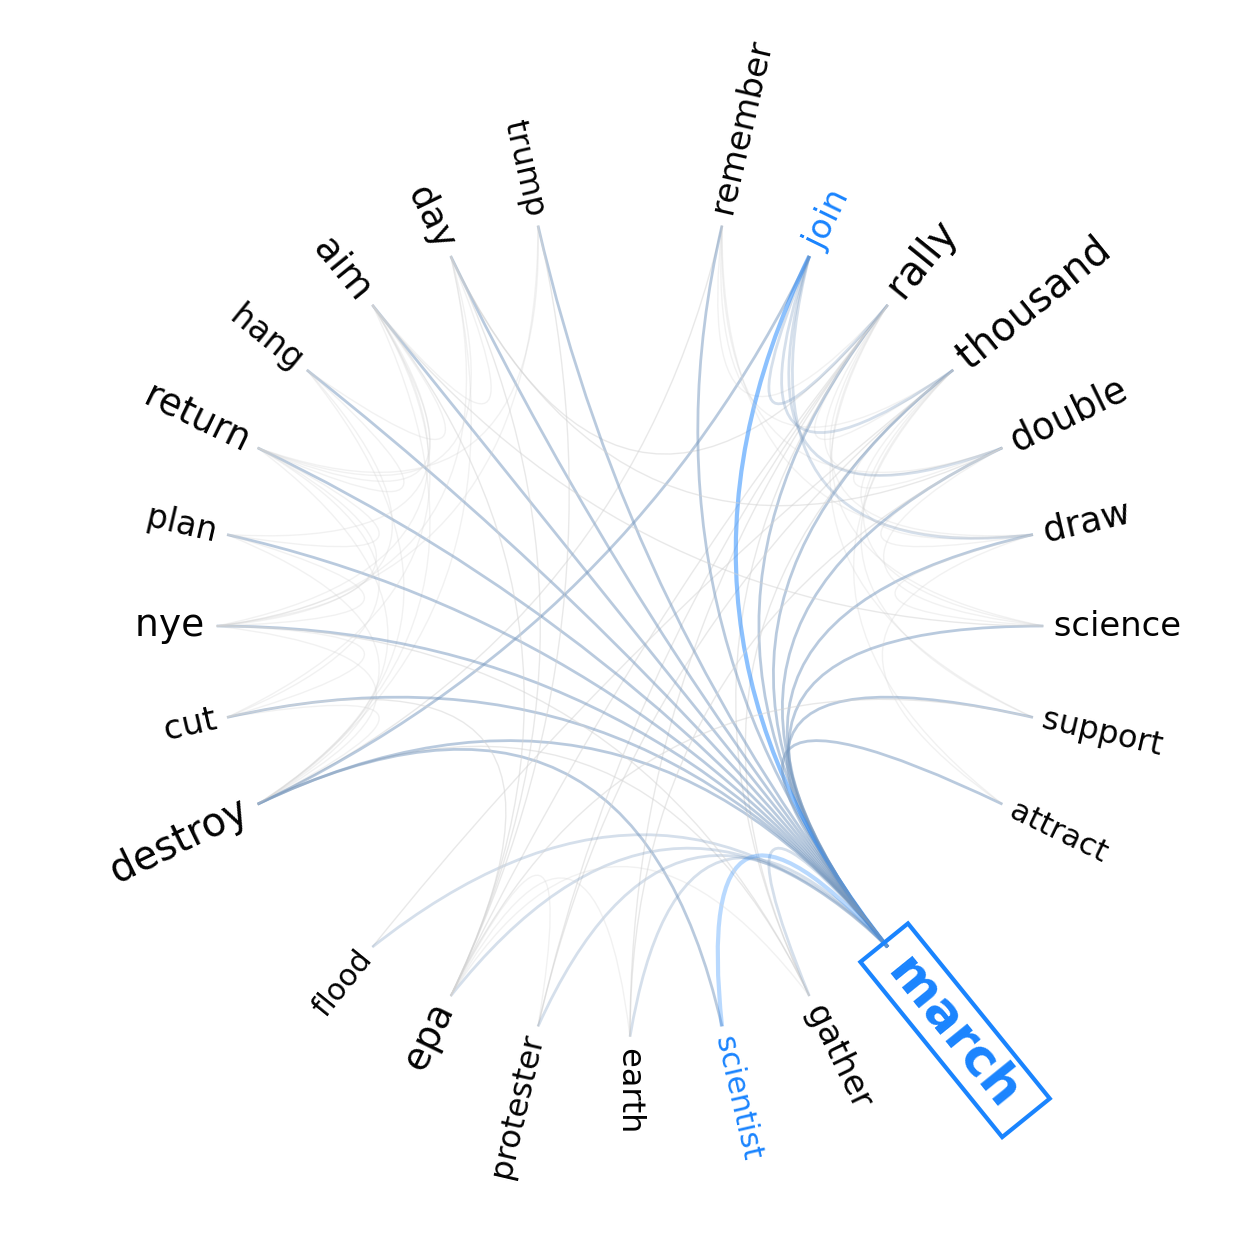

In [61]:
focal_graph = emo.formamentis_to_nxgraph(focal_fmn)
closeness_dict = nx.closeness_centrality(focal_graph)

top_terms_df_focal = pd.DataFrame(
    {
        "term": list(focal_graph.nodes()),
        "closeness": [closeness_dict[node] for node in focal_graph.nodes()],
    }
)

# go over all the edges, only keep the ones with third quartile salience
t=np.quantile(list(top_terms_df_focal['closeness']),0.75)
df_t=top_terms_df_focal[top_terms_df_focal['closeness']>t]
top_edges=[]
top_nodes=df_t['term'][:10]



for v in top_nodes:
    for (e1,e2) in list(focal_graph.edges):
        if v in (e1,e2):
                    if e1 in list(df_t['term']) and e2 in list(df_t['term']):
                             top_edges.append((e1,e2))

top_graph=nx.Graph()
top_graph.add_nodes_from(top_nodes)
top_graph.add_edges_from(top_edges)

top_focal_fmnt=emo.nxgraph_to_formamentis(top_graph)

top_edges
emo.draw_formamentis(top_focal_fmnt, highlight=[focal_term])

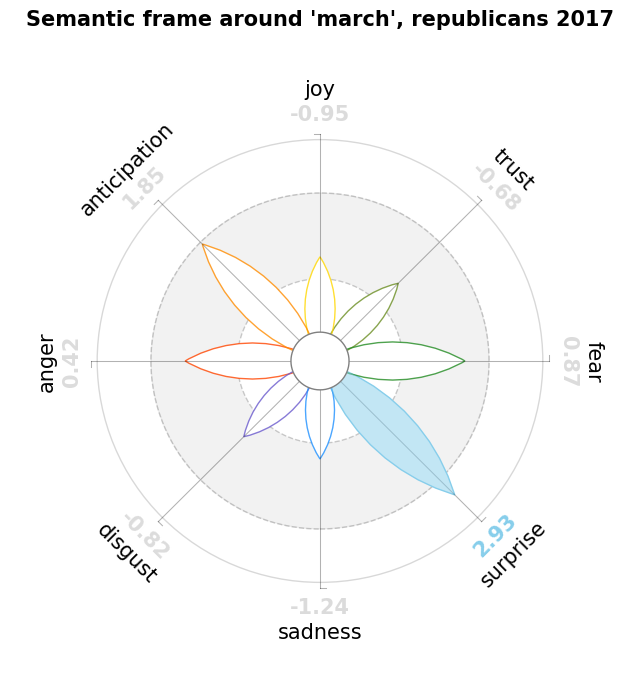

In [62]:
emo.draw_statistically_significant_emotions(
    focal_fmn,
    title=f"Semantic frame around '{focal_term}', republicans 2017",
)

And then you can save all key outputs for downstream work

In [63]:
# from pathlib import Path
# OUTPUT_DIR = Path("./emoatlas_outputs_republicans")
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# # Core tabular outputs
# df_2016.to_pickle(OUTPUT_DIR / "all_json_flattened.pkl")
# df_2016.to_csv(OUTPUT_DIR / "all_json_flattened.csv", index=False)

# df_2017.to_pickle(OUTPUT_DIR / "all_json_flattened.pkl")
# df_2017.to_csv(OUTPUT_DIR / "all_json_flattened.csv", index=False)


# # network_stats_df.to_csv(OUTPUT_DIR / "first_50_tfmn_stats.csv", index=False)
# top_terms_df_2016.to_csv(OUTPUT_DIR / "combined_network_top_terms_2016.csv", index=False)

# top_terms_df_2017.to_csv(OUTPUT_DIR / "combined_network_top_terms_2017.csv", index=False)


# # Export the aggregated formamentis network as a simple text edgelist
# emo.export_formamentis(
#     fmnt_2016,
#     filename="2016_formamentis.txt",
#     path=str(OUTPUT_DIR),
# )

# emo.export_formamentis(
#     fmnt_2017,
#     filename="2017_formamentis.txt",
#     path=str(OUTPUT_DIR),
# )

# print("Saved output files:")
# for path in sorted(OUTPUT_DIR.iterdir()):
#     print("-", path)